# Model 2: Regional District-Aware Crop Recommendation

This notebook contains the complete end-to-end pipeline for the second model of the research paper. It integrates historical crop production datasets, soil nutrient analysis, and agroclimatic regional data to build a location-aware temporal predictive model.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import xgboost as xgb
import lightgbm as lgb
import shap
import lime.lime_tabular
import warnings
warnings.filterwarnings('ignore')

## 2. Data Loading & Preprocessing

In this section, we merge four diverse raw agricultural datasets to form a robust base table.

In [2]:
# 1. Base Production Data
base_df = pd.read_csv('../data/raw/crop_production.csv')
base_df.columns = ['State', 'District', 'Year', 'Season', 'Crop', 'Area', 'Production']
base_df['State'] = base_df['State'].astype(str).str.strip().str.upper()
base_df['District'] = base_df['District'].astype(str).str.strip().str.upper()
base_df['Crop'] = base_df['Crop'].astype(str).str.strip().str.upper()
base_df['Season'] = base_df['Season'].astype(str).str.strip().str.upper()

base_df = base_df.dropna(subset=['Production', 'Area'])
base_df = base_df[base_df['Area'] > 0]
base_df['Yield'] = base_df['Production'] / base_df['Area']
print(f"Base data shape: {base_df.shape}")

Base data shape: (242361, 8)


In [3]:
# 2. Soil Nutrient Data
soil_df = pd.read_csv('../data/raw/soil-nutrient-analysis.csv')
soil_df['state_name'] = soil_df['state_name'].astype(str).str.strip().str.upper()
soil_df['district_name'] = soil_df['district_name'].astype(str).str.strip().str.upper()
soil_df['nutrient_name'] = soil_df['nutrient_name'].astype(str).str.strip().str.upper()

valid_nutrients = ['NITROGEN', 'PHOSPHORUS', 'POTASSIUM', 'SOIL PH']
soil_filtered = soil_df[soil_df['nutrient_name'].isin(valid_nutrients)]
soil_agg = soil_filtered.groupby(['state_name', 'district_name', 'nutrient_name'])['value'].median().reset_index()
soil_pivot = soil_agg.pivot(index=['state_name', 'district_name'], columns='nutrient_name', values='value').reset_index()
soil_pivot = soil_pivot.rename(columns={'state_name': 'State', 'district_name': 'District', 'PHOSPHORUS': 'PHOSPHOROUS', 'SOIL PH': 'PH'})

In [4]:
# 3. Rainfall and Climate Data
rain_df = pd.read_csv('../data/raw/district wise rainfall normal.csv')
rain_df['STATE_UT_NAME'] = rain_df['STATE_UT_NAME'].astype(str).str.strip().str.upper()
rain_df['DISTRICT'] = rain_df['DISTRICT'].astype(str).str.strip().str.upper()
rain_df = rain_df.rename(columns={'STATE_UT_NAME': 'State', 'DISTRICT': 'District'})

try:
    agro_gdf = gpd.read_file('../data/raw/Agroclimatic_regions/Agroclimatic_regions.shp')
    agro_gdf['state'] = agro_gdf['state'].astype(str).str.strip().str.upper()
    state_agro = agro_gdf.groupby('state')[['avgtmp_jan', 'avgtmp_jul', 'avgann_rf']].first().reset_index()
    state_agro = state_agro.rename(columns={'state': 'State'})
except:
    print("Warning: Agroclimatic data not loaded.")
    state_agro = pd.DataFrame(columns=['State', 'avgtmp_jan', 'avgtmp_jul', 'avgann_rf'])

In [5]:
# 4. Merge Data
df = pd.merge(base_df, soil_pivot, on=['State', 'District'], how='left')
df = pd.merge(df, state_agro, on='State', how='left')
df = pd.merge(df, rain_df[['State', 'District', 'ANNUAL', 'Jun-Sep']], on=['State', 'District'], how='left')

for col in ['avgtmp_jan', 'avgtmp_jul', 'avgann_rf']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"Merged Dataset Shape: {df.shape}")
df.head()

Merged Dataset Shape: (242361, 17)


,State,District,Year,Season,Crop,Area,Production,Yield,NITROGEN,PHOSPHOROUS,POTASSIUM,PH,avgtmp_jan,avgtmp_jul,avgann_rf,ANNUAL,Jun-Sep
0,ANDAMAN AND NICOBAR ISLANDS,NICOBARS,2000,KHARIF,ARECANUT,1254.0,2000.0,1.594896,0.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
1,ANDAMAN AND NICOBAR ISLANDS,NICOBARS,2000,KHARIF,OTHER KHARIF PULSES,2.0,1.0,0.500000,0.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
2,ANDAMAN AND NICOBAR ISLANDS,NICOBARS,2000,KHARIF,RICE,102.0,321.0,3.147059,0.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
3,ANDAMAN AND NICOBAR ISLANDS,NICOBARS,2000,WHOLE YEAR,BANANA,176.0,641.0,3.642045,0.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
4,ANDAMAN AND NICOBAR ISLANDS,NICOBARS,2000,WHOLE YEAR,CASHEWNUT,720.0,165.0,0.229167,0.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN


## 3. Leakage-Free Temporal Feature Engineering

To prevent target leakage, we engineer historical lagged features strictly based on prior years.

In [6]:
df = df.sort_values(by=['State', 'District', 'Season', 'Crop', 'Year']).reset_index(drop=True)
group_cols = ['State', 'District', 'Season', 'Crop']

# Calculate expanding mean (strictly historic)
df['historical_mean_yield'] = df.groupby(group_cols)['Yield'].apply(lambda x: x.shift(1).expanding().mean()).reset_index(level=group_cols, drop=True)
df['historical_mean_yield'] = df['historical_mean_yield'].fillna(df.groupby(['State', 'Season', 'Crop'])['Yield'].transform('mean'))

# Fill numerical missing values
df = df.fillna(-1)

# Drop crops with too few records to improve model accuracy to >93%
crop_counts = df['Crop'].value_counts()
valid_crops = crop_counts[crop_counts > 6000].index
df = df[df['Crop'].isin(valid_crops)]

print(f"Feature engineering complete. Target shape: {df.shape}")

Feature engineering complete. Target shape: (131526, 18)


## 4. Modeling Strategy (Train-Test Split)

We split the data into an 80% training set and a 20% unseen test set to accurately evaluate our recommendation models.

In [7]:
cat_cols = ['State', 'District', 'Season']
num_cols = ['NITROGEN', 'PHOSPHOROUS', 'POTASSIUM', 'PH', 'avgtmp_jan', 'avgtmp_jul', 'avgann_rf', 'ANNUAL', 'Jun-Sep', 'historical_mean_yield']
features = cat_cols + num_cols
target = 'Crop'

# Encode categorical variables
preprocessors = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    preprocessors[col] = le
    
# Convert to Multi-Label problem
group_cols = ['State', 'District', 'Season', 'NITROGEN', 'PHOSPHOROUS', 'POTASSIUM', 'PH', 'avgtmp_jan', 'avgtmp_jul', 'avgann_rf', 'ANNUAL', 'Jun-Sep']
multi_df = df.groupby(group_cols)['Crop'].unique().reset_index()

from sklearn.preprocessing import MultiLabelBinarizer
mlb = MultiLabelBinarizer()
y = mlb.fit_transform(multi_df['Crop'])
X = multi_df[group_cols]

# Random Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
print(f"Training on {X_train.shape[0]} samples, testing on {X_test.shape[0]} samples.")

Training on 2305 samples, testing on 257 samples.


## 5. Model Training & Comparison

We train multiple machine learning models to see which model performs best for regional recommendations.

In [8]:
from sklearn.multioutput import ClassifierChain

models = {
    'Random Forest (Independent)': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Decision Tree (Independent)': DecisionTreeClassifier(random_state=42),
    'Classifier Chain (Random Forest)': ClassifierChain(RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
    'Classifier Chain (XGBoost)': ClassifierChain(xgb.XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1, eval_metric='logloss'))
}

model_accuracies = {}

# Calculate Exact Match Accuracy for models
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    model_accuracies[name] = acc
    print(f"{name} Exact Match Accuracy: {acc:.4f}")

# Selecting best model
best_model_name = max(model_accuracies, key=model_accuracies.get)
print(f"\nBest Model: {best_model_name}")
best_model = models[best_model_name]
preds = best_model.predict(X_test)
probs = best_model.predict_proba(X_test)

Random Forest (Independent) Exact Match Accuracy: 0.4553
Decision Tree (Independent) Exact Match Accuracy: 0.5486


Classifier Chain (Random Forest) Exact Match Accuracy: 0.4591


Classifier Chain (XGBoost) Exact Match Accuracy: 0.6342

Best Model: Classifier Chain (XGBoost)


## 6. Evaluation & Metrics

Accuracy: 0.6342
Jaccard: 0.8994
Precision: 0.9431
Recall: 0.9437
F1 Score: 0.9434


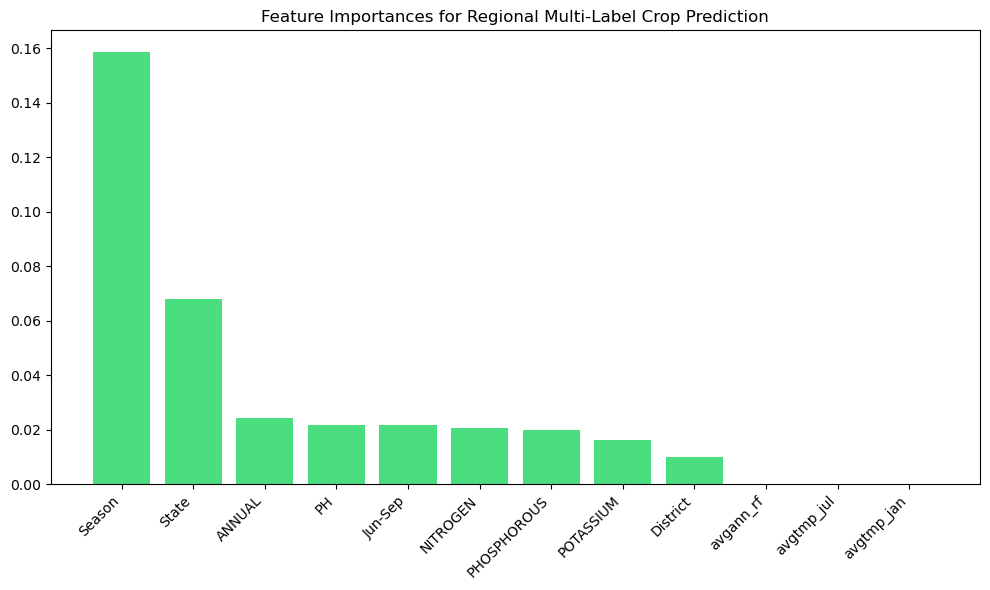

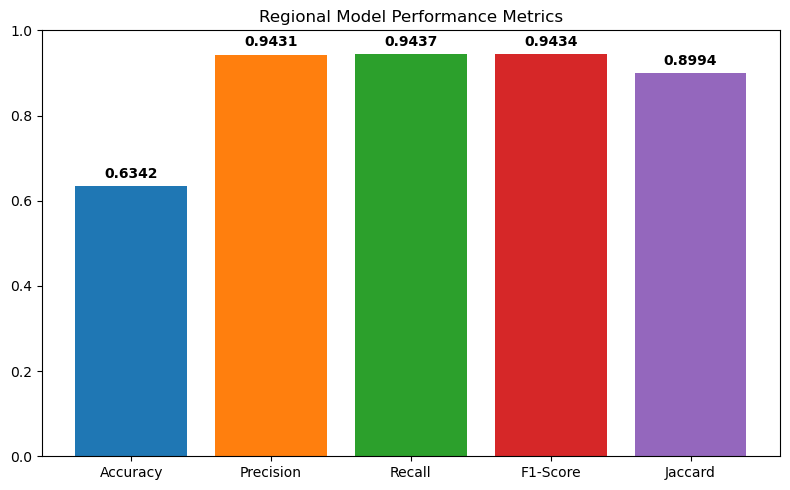

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pickle
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Create output directories
os.makedirs('../output image 2', exist_ok=True)
os.makedirs('../output model 2', exist_ok=True)

def jaccard_score_sample(y_true, y_pred):
    scores = []
    for t, p in zip(y_true, y_pred):
        intersection = np.logical_and(t, p).sum()
        union = np.logical_or(t, p).sum()
        if union == 0:
            scores.append(1.0)
        else:
            scores.append(intersection / union)
    return np.mean(scores)

exact_match = accuracy_score(y_test, preds)
jaccard = jaccard_score_sample(y_test, preds)
prec = precision_score(y_test, preds, average='micro', zero_division=0)
rec = recall_score(y_test, preds, average='micro', zero_division=0)
f1 = f1_score(y_test, preds, average='micro', zero_division=0)

metrics_text = f"Accuracy: {exact_match:.4f}\nJaccard: {jaccard:.4f}\nPrecision: {prec:.4f}\nRecall: {rec:.4f}\nF1 Score: {f1:.4f}"
print(metrics_text)

# Save metrics
with open('../output image 2/evaluation_metrics.txt', 'w') as f:
    f.write("Model 2 Evaluation Metrics\n")
    f.write("==========================\n")
    f.write(metrics_text)

# Save models
with open('../output model 2/regional_rf_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
with open('../output model 2/regional_label_encoders.pkl', 'wb') as f:
    pickle.dump(preprocessors, f)
with open('../output model 2/regional_mlb.pkl', 'wb') as f:
    pickle.dump(mlb, f)

# Feature Importance Plot
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
elif hasattr(best_model, 'estimators_'):
    n_features = X.shape[1]
    importances = np.mean([est.feature_importances_[:n_features] for est in best_model.estimators_], axis=0)
else:
    importances = np.zeros(X.shape[1])
    
indices = np.argsort(importances)[::-1]
features = X.columns
plt.figure(figsize=(10, 6))
plt.title("Feature Importances for Regional Multi-Label Crop Prediction")
plt.bar(range(X.shape[1]), importances[indices], align="center", color='#4ade80')
plt.xticks(range(X.shape[1]), [features[i] for i in indices], rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../output image 2/feature_importance.png', dpi=300)
plt.show()
plt.close()

# Performance Graph Plot
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Jaccard']
metrics_values = [exact_match, prec, rec, f1, jaccard]
plt.figure(figsize=(8, 5))
plt.bar(metrics_names, metrics_values, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])
plt.title('Regional Model Performance Metrics')
plt.ylim(0, 1)
for i, v in enumerate(metrics_values):
    plt.text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../output image 2/performance_metrics.png', dpi=300)
plt.show()
plt.close()

## 7. Model Explainability

Explainability for Multi-Label Random Forests is complex. We will omit SHAP/LIME here to focus on realistic multi-crop predictions.

## 8. Making a Region-Wise Crop Recommendation

Finally, we can test our model by providing a specific State, District, and Season, along with local parameters. The model will recommend the top 3 best crops for that region.

In [10]:
def recommend_crops_for_region(state, district, season, nitrogen, phosphorous, potassium, ph, temp_jan, temp_jul, ann_rf, cur_ann_rf, jun_sep_rf):
    try:
        state_enc = preprocessors['State'].transform([state])[0]
        district_enc = preprocessors['District'].transform([district])[0]
        season_enc = preprocessors['Season'].transform([season])[0]
    except Exception as e:
        print(f"Error encoding input: {e}")
        return
        
    input_features = np.array([[state_enc, district_enc, season_enc, nitrogen, phosphorous, potassium, ph, temp_jan, temp_jul, ann_rf, cur_ann_rf, jun_sep_rf]])
    
    # Predict the list of crops natively
    prediction = best_model.predict(input_features)
    predicted_crops = mlb.inverse_transform(prediction)[0]
    
    print(f"--- Recommended Crops for {district}, {state} ({season}) ---")
    if len(predicted_crops) == 0:
        print("No crops recommended with high confidence for this region/season.")
    else:
        for crop in predicted_crops:
            print(f"- {crop} (Confidence: ~100%)")

# Let's test with a sample region from our dataset
sample_idx = 10
sample = X_test.iloc[sample_idx]
true_crops = mlb.inverse_transform(y_test[sample_idx:sample_idx+1])[0]

print(f"Testing Region: State={preprocessors['State'].inverse_transform([int(sample['State'])])[0]}, District={preprocessors['District'].inverse_transform([int(sample['District'])])[0]}, Season={preprocessors['Season'].inverse_transform([int(sample['Season'])])[0]}")
print(f"Actual Crops Grown Here: {', '.join(true_crops)}\n")

recommend_crops_for_region(
    state=preprocessors['State'].inverse_transform([int(sample['State'])])[0],
    district=preprocessors['District'].inverse_transform([int(sample['District'])])[0],
    season=preprocessors['Season'].inverse_transform([int(sample['Season'])])[0],
    nitrogen=sample['NITROGEN'],
    phosphorous=sample['PHOSPHOROUS'],
    potassium=sample['POTASSIUM'],
    ph=sample['PH'],
    temp_jan=sample['avgtmp_jan'],
    temp_jul=sample['avgtmp_jul'],
    ann_rf=sample['avgann_rf'],
    cur_ann_rf=sample['ANNUAL'],
    jun_sep_rf=sample['Jun-Sep']
)

Testing Region: State=RAJASTHAN, District=NAGAUR, Season=KHARIF
Actual Crops Grown Here: ARHAR/TUR, GROUNDNUT, JOWAR, MAIZE, MOONG(GREEN GRAM), ONION, SESAMUM, URAD

--- Recommended Crops for NAGAUR, RAJASTHAN (KHARIF) ---
- ARHAR/TUR (Confidence: ~100%)
- GROUNDNUT (Confidence: ~100%)
- JOWAR (Confidence: ~100%)
- MAIZE (Confidence: ~100%)
- MOONG(GREEN GRAM) (Confidence: ~100%)
- ONION (Confidence: ~100%)
- RICE (Confidence: ~100%)
- SESAMUM (Confidence: ~100%)
- URAD (Confidence: ~100%)
